In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.ensemble import IsolationForest

# Wyłączanie anty-aliasowania (zniekształca wykresy)
mpl.rcParams['image.interpolation'] = 'nearest'

Wczytanie obrazka, przygotowanie prostej aproksymacji RGB, 
2D kostki danych (X), wykres RGB i przykładowych wektorów hiperspektralnych.

In [2]:
data = np.load('indian_pines.npy')
rgb = np.array(data[:, :, np.array([29, 20, 11])], float) / np.max(data)
X = np.reshape(data, (-1, data.shape[-1]))
bands = np.linspace(400, 2500, data.shape[-1])
ground_truth = np.load('gt.npy')
y = ground_truth.ravel()

Wykrywanie anomalii - IsolationForest
-------------------------------------

Wybieramy losowo atrybut, następnie losowo wartość. Ile razy musimy to 
powtórzyć, żeby wyizolować dany punkt?

![10.1109/TKDE.2019.2947676](if.jpg)

In [4]:
selected_class = 11 # Analizujemy wybraną klasę

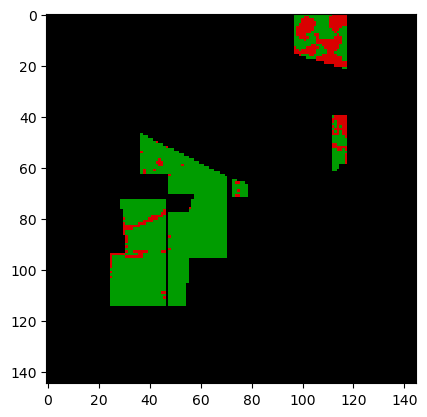

In [5]:
index_selected = y == selected_class
X_selected = X[index_selected] # Przykłady wybranej klasy

clf = IsolationForest(random_state=0)
anomalies = clf.fit_predict(X_selected) # Przykłady OK 1, anomalie -1
index_anomalies = np.flatnonzero(index_selected)[anomalies == -1]

labels = np.zeros_like(y)
labels[index_selected] = 1
labels[index_anomalies] = 2

plt.imshow(labels.reshape(data.shape[:2]), cmap=plt.cm.nipy_spectral, vmax=2.2)
plt.show()

Podgląd przykładów wskazanych jako anomalie

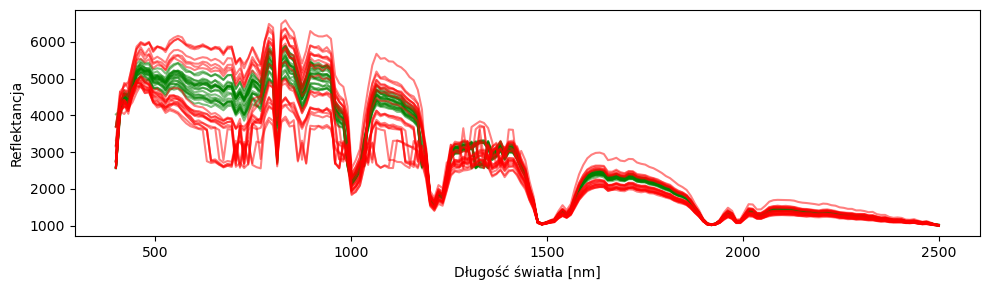

In [6]:
X_ok = X_selected[anomalies == 1]
X_anomalies = X_selected[anomalies == -1]

plt.figure(figsize=(10, 3))
for i in np.random.choice(len(X_ok), size=20, replace=False): 
    plt.plot(bands, X_ok[i], c='g', alpha=0.5)
for i in np.random.choice(len(X_anomalies), size=20, replace=False): 
    plt.plot(bands, X_anomalies[i], c='r', alpha=0.5)
plt.ylabel('Reflektancja')
plt.xlabel('Długość światła [nm]')
plt.tight_layout()
plt.show()